# Introduction
This notebook is the Hands-On Week 3 assignment for the Predictive Analytics and Machine Learning Using Python course at BSBI. It involves exploratory data analysis (EDA) of the world_population.csv dataset, covering population density data for 251 countries from 1960 to 2016.

The primary tasks are:

*   Identify the top-populated countries by defined time intervals and continents.
*   Analyze the population trend of the most populated country over the years.

The dataset is assumed to be credible, original, and properly cited, as provided by the course professor.

In [1]:
#### Installing the required packages and importing libraries

!pip install country_converter

import pandas as pd
import numpy as np1
import matplotlib.pyplot as plt
import seaborn as sns
import country_converter as coco

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.9 MB/s eta 0:00:00


In [2]:
### Reading the World Population Dataset
df = pd.read_csv('/content/world_population.csv')

In [3]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,307.972222,312.366667,314.983333,316.827778,318.666667,...,562.322222,563.011111,563.422222,564.427778,566.311111,568.850000,571.783333,574.672222,577.161111,NaN
1,Andorra,AND,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,30.587234,32.714894,34.914894,37.170213,39.470213,...,180.591489,182.161702,181.859574,179.614894,175.161702,168.757447,161.493617,154.863830,149.942553,NaN
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,14.038148,14.312061,14.599692,14.901579,15.218206,...,39.637202,40.634655,41.674005,42.830327,44.127634,45.533197,46.997059,48.444546,49.821649,NaN
3,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,4.305195,4.384299,4.464433,4.544558,4.624228,...,15.387749,15.915819,16.459536,17.020898,17.600302,18.196544,18.808215,19.433323,20.070565,NaN
4,Albania,ALB,Population density (people per sq. km of land ...,EN.POP.DNST,NaN,60.576642,62.456898,64.329234,66.209307,68.058066,...,108.394781,107.566204,106.843759,106.314635,106.013869,105.848431,105.717226,105.607810,105.444051,NaN


# Prepare
Prepare the dataset for analysis by handling missing values, standardizing column names, reshaping the data, and creating time intervals for aggregation. The steps include checking for NA values, removing null columns, checking duplicates, melting the dataset, and binning years into intervals.

In [4]:
df.shape

(264, 61)

In [5]:
df.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
count,0.0,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,...,262.000000,262.000000,262.000000,262.000000,262.000000,261.000000,261.000000,261.000000,261.000000,0.0
mean,NaN,176.915141,180.703231,184.572413,188.461797,192.412363,196.145042,200.118063,203.879464,207.336102,...,331.995474,338.688417,343.649206,347.967029,351.942027,357.787305,360.985726,364.849194,368.706601,NaN
std,NaN,943.335678,962.152018,981.766557,1002.141213,1023.607719,1045.338502,1068.523145,1090.949797,1110.937670,...,1609.484372,1648.598395,1677.038735,1702.633159,1723.824030,1750.278657,1759.146632,1776.826139,1794.612550,NaN
min,NaN,0.098625,0.102429,0.106526,0.110038,0.114721,0.118525,0.122622,0.127012,0.131402,...,0.137788,0.137235,0.137223,0.138641,0.138604,0.138409,0.137612,0.137154,0.136713,NaN
25%,NaN,10.550711,10.832306,11.078952,11.329188,11.582654,11.839337,12.098215,12.356687,12.737931,...,32.174322,32.567591,32.910747,33.110597,33.371288,33.846424,34.560225,34.732983,35.137648,NaN
50%,NaN,26.403402,26.888150,27.521085,28.428442,29.373887,30.358488,31.114555,31.752903,32.385777,...,70.270106,70.375883,70.825337,72.591929,74.427908,75.883270,76.770006,78.303701,78.581380,NaN
75%,NaN,86.646634,87.879176,89.023222,89.965509,90.872827,91.718628,92.973684,94.871324,95.712623,...,160.981446,164.566044,168.296465,174.204832,178.652138,184.723259,189.747705,194.106250,198.275000,NaN
max,NaN,11406.000000,11521.000000,11584.500000,11618.500000,11641.500000,11652.000000,11648.500000,11856.450000,12265.500000,...,17523.000000,17865.500000,18175.500000,18422.500000,18594.500000,18702.000000,18764.000000,19073.069307,19392.937294,NaN


In [6]:
# Check for NA values
df.isnull().sum()

,0
Country Name,0
Country Code,0
Indicator Name,0
Indicator Code,0
1960,264
...,...
2012,3
2013,3
2014,3
2015,3


In [7]:
### The dataset has missing values for 1960 and 2016
#  Make a copy and remove columns with all null values
df1 = df.copy()
df1 = df1.dropna(axis=1, how='all')
df1 = df1.dropna()
df1

,Country Name,Country Code,Indicator Name,Indicator Code,1961,1962,1963,1964,1965,1966,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,307.972222,312.366667,314.983333,316.827778,318.666667,320.622222,...,560.166667,562.322222,563.011111,563.422222,564.427778,566.311111,568.850000,571.783333,574.672222,577.161111
1,Andorra,AND,Population density (people per sq. km of land ...,EN.POP.DNST,30.587234,32.714894,34.914894,37.170213,39.470213,41.800000,...,177.389362,180.591489,182.161702,181.859574,179.614894,175.161702,168.757447,161.493617,154.863830,149.942553
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,14.038148,14.312061,14.599692,14.901579,15.218206,15.545203,...,38.574296,39.637202,40.634655,41.674005,42.830327,44.127634,45.533197,46.997059,48.444546,49.821649
3,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,4.305195,4.384299,4.464433,4.544558,4.624228,4.703271,...,14.872437,15.387749,15.915819,16.459536,17.020898,17.600302,18.196544,18.808215,19.433323,20.070565
4,Albania,ALB,Population density (people per sq. km of land ...,EN.POP.DNST,60.576642,62.456898,64.329234,66.209307,68.058066,69.874927,...,109.217044,108.394781,107.566204,106.843759,106.314635,106.013869,105.848431,105.717226,105.607810,105.444051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,"Yemen, Rep.",YEM,Population density (people per sq. km of land ...,EN.POP.DNST,9.946897,10.112857,10.283730,10.460234,10.642972,10.834968,...,39.952976,41.102913,42.280241,43.476383,44.684304,45.902116,47.129178,48.361113,49.593113,50.821477
260,South Africa,ZAF,Population density (people per sq. km of land ...,EN.POP.DNST,14.796892,15.216878,15.609838,15.984431,16.348334,16.708236,...,39.503814,40.060326,40.636905,41.234300,41.853305,42.494751,43.159519,43.848532,44.562767,45.303251
261,"Congo, Dem. Rep.",COD,Population density (people per sq. km of land ...,EN.POP.DNST,6.897825,7.075824,7.261381,7.456342,7.661877,7.878900,...,25.551638,26.393275,27.264188,28.162192,29.085689,30.033469,31.005562,32.003203,33.028398,34.082536
262,Zambia,ZMB,Population density (people per sq. km of land ...,EN.POP.DNST,4.227724,4.359305,4.496824,4.639914,4.788452,4.942343,...,16.655469,17.135926,17.641587,18.170609,18.721585,19.294752,19.890745,20.508866,21.148177,21.807890


In [8]:
df1.describe()

,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
count,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,...,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000,251.000000
mean,178.202097,182.009929,185.898110,189.805890,193.775042,197.524399,201.515746,205.293496,208.763678,212.047081,...,328.872818,333.950152,340.709941,345.924044,350.729096,354.963992,359.534773,362.475290,366.211407,369.937442
std,946.990441,965.880689,985.572527,1006.027685,1027.579122,1049.396216,1072.672831,1095.188646,1115.256117,1132.271895,...,1619.571815,1643.160885,1683.084392,1712.228855,1738.571597,1760.313092,1783.968107,1792.916448,1810.892921,1828.973606
min,0.098625,0.102429,0.106526,0.110038,0.114721,0.118525,0.122622,0.127012,0.131402,0.135792,...,0.138321,0.137788,0.137235,0.137223,0.138641,0.138604,0.138409,0.137612,0.137154,0.136713
25%,10.532892,10.793386,11.018515,11.240721,11.506891,11.824179,12.053100,12.346925,12.674683,12.998683,...,31.176415,31.499061,31.709568,32.054787,32.510298,32.905834,32.992327,33.578235,34.101700,34.304520
50%,27.064630,28.004705,28.557177,29.163459,29.801751,30.454396,31.114555,31.752903,32.385777,33.202356,...,65.011860,65.979826,68.110097,69.005880,70.858335,72.776389,73.905870,74.678379,75.739618,75.489707
75%,86.895739,87.995596,89.075810,90.136584,91.114719,91.980436,92.979371,95.057592,96.587890,97.262275,...,146.075751,150.961470,156.006487,161.142088,164.209103,167.680830,171.184236,176.356678,182.083650,187.566949
max,11406.000000,11521.000000,11584.500000,11618.500000,11641.500000,11652.000000,11648.500000,11856.450000,12265.500000,12549.850000,...,17192.000000,17523.000000,17865.500000,18175.500000,18422.500000,18594.500000,18702.000000,18764.000000,19073.069307,19392.937294


In [9]:
# Count duplicates
df1.duplicated().sum()

np.int64(0)

In [10]:
# Standardize column names (for consistency)
df1.columns = df1.columns.str.lower().str.replace(' ', '_')
df1.head()

,country_name,country_code,indicator_name,indicator_code,1961,1962,1963,1964,1965,1966,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,307.972222,312.366667,314.983333,316.827778,318.666667,320.622222,...,560.166667,562.322222,563.011111,563.422222,564.427778,566.311111,568.850000,571.783333,574.672222,577.161111
1,Andorra,AND,Population density (people per sq. km of land ...,EN.POP.DNST,30.587234,32.714894,34.914894,37.170213,39.470213,41.800000,...,177.389362,180.591489,182.161702,181.859574,179.614894,175.161702,168.757447,161.493617,154.863830,149.942553
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,14.038148,14.312061,14.599692,14.901579,15.218206,15.545203,...,38.574296,39.637202,40.634655,41.674005,42.830327,44.127634,45.533197,46.997059,48.444546,49.821649
3,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,4.305195,4.384299,4.464433,4.544558,4.624228,4.703271,...,14.872437,15.387749,15.915819,16.459536,17.020898,17.600302,18.196544,18.808215,19.433323,20.070565
4,Albania,ALB,Population density (people per sq. km of land ...,EN.POP.DNST,60.576642,62.456898,64.329234,66.209307,68.058066,69.874927,...,109.217044,108.394781,107.566204,106.843759,106.314635,106.013869,105.848431,105.717226,105.607810,105.444051


In [49]:
# Melt the dataset: convert year columns into rows
df_melted = df1.melt(
    id_vars=['country_name', 'country_code', 'indicator_name', 'indicator_code'],
    var_name='year',
    value_name='population_density'
)

In [50]:
# Convert year to numeric (some columns might have whitespace or be string type)
df_melted['year'] = pd.to_numeric(df_melted['year'], errors='coerce')



In [51]:
# Drop rows with missing population values
df_melted = df_melted.dropna(subset=['population_density'])

In [52]:
# View head
df_melted.head()

,country_name,country_code,indicator_name,indicator_code,year,population_density
0,Aruba,ABW,Population density (people per sq. km of land ...,EN.POP.DNST,1961,307.972222
1,Andorra,AND,Population density (people per sq. km of land ...,EN.POP.DNST,1961,30.587234
2,Afghanistan,AFG,Population density (people per sq. km of land ...,EN.POP.DNST,1961,14.038148
3,Angola,AGO,Population density (people per sq. km of land ...,EN.POP.DNST,1961,4.305195
4,Albania,ALB,Population density (people per sq. km of land ...,EN.POP.DNST,1961,60.576642


In [53]:
# Define bins and labels for the intervals
bins = [1961, 1975, 1990, 2005, 2020]  # Define the edges of the intervals
labels = ['1961-1975', '1976-1990', '1991-2005', '2006-2020']  # Define labels for the intervals

# Create a new column for the intervals
df_new = df_melted.copy()
df_new['interval'] = pd.cut(df_new['year'], bins=bins, labels=labels, right=True)

# Aggregate population density by country and interval
df_new= df_new.groupby(['country_name','interval'], observed=True)['population_density'].sum().reset_index()

# Get top population in countries by interval
top_countries = df_new.sort_values(by='population_density', ascending=False).head(20)

# Display the DataFrame with intervals
top_countries

,country_name,interval,population_density
562,"Macao SAR, China",1991-2005,283892.246663
626,Monaco,1991-2005,236738.000000
561,"Macao SAR, China",1976-1990,213109.650000
625,Monaco,1976-1990,208500.500000
627,Monaco,2006-2020,182916.000000
563,"Macao SAR, China",2006-2020,180857.729045
624,Monaco,1961-1975,165855.000000
560,"Macao SAR, China",1961-1975,160574.950000
394,"Hong Kong SAR, China",1991-2005,92947.113997
798,Singapore,1991-2005,84327.306441


In [54]:
# Convert countries to continents
cc = coco.CountryConverter()
top_countries['continent'] = cc.convert(names=top_countries['country_name'].tolist(), to='continent')

# Check for unmapped countries
top_countries[top_countries['continent'] == 'not found']['country_name'].unique()

# Remove unmapped countries
top_countries = top_countries[top_countries['continent'] != 'not found']
top_countries

,country_name,interval,population_density,continent
562,"Macao SAR, China",1991-2005,283892.246663,Asia
626,Monaco,1991-2005,236738.000000,Europe
561,"Macao SAR, China",1976-1990,213109.650000,Asia
625,Monaco,1976-1990,208500.500000,Europe
627,Monaco,2006-2020,182916.000000,Europe
563,"Macao SAR, China",2006-2020,180857.729045,Asia
624,Monaco,1961-1975,165855.000000,Europe
560,"Macao SAR, China",1961-1975,160574.950000,Asia
394,"Hong Kong SAR, China",1991-2005,92947.113997,Asia
798,Singapore,1991-2005,84327.306441,Asia


# Analyze
Analyze the dataset to identify top-populated countries by time intervals and continents, and visualize population trends

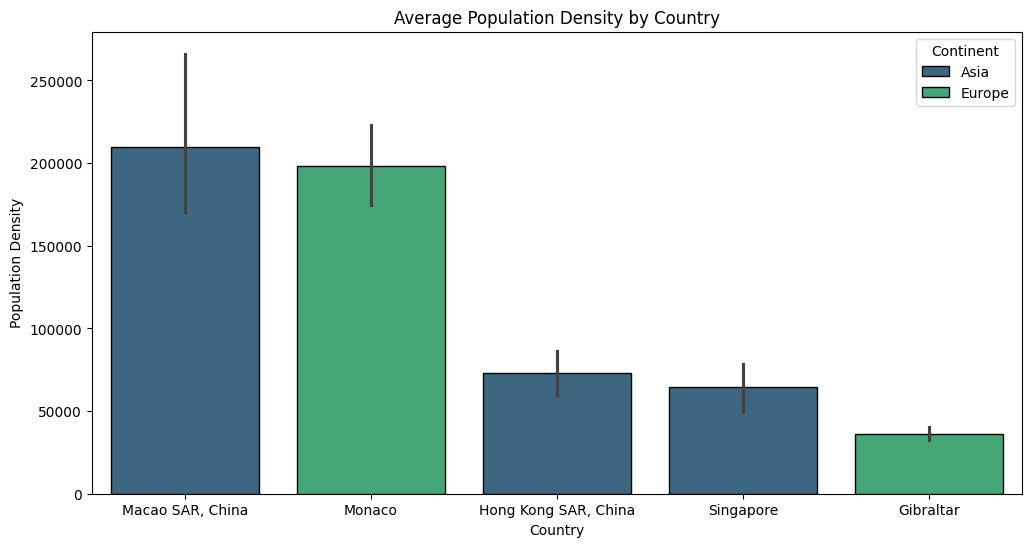

In [70]:
# Plot graph for country and population density
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='country_name', y='population_density', hue='continent', edgecolor='black', palette= 'viridis')
plt.legend(title='Continent')
plt.title("Average Population Density by Country")
plt.xlabel("Country")
plt.ylabel("Population Density")
plt.show()

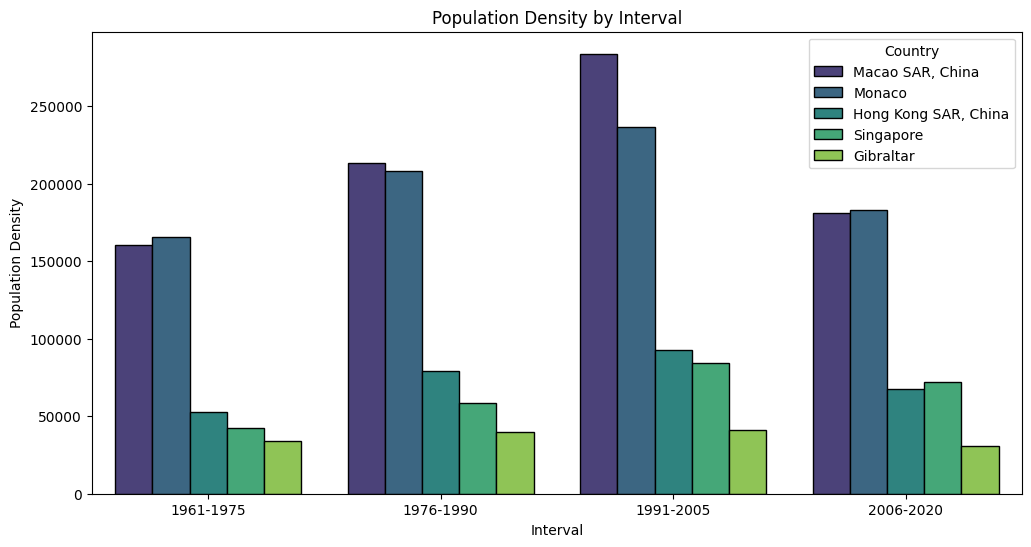

In [56]:
# Plot graph for population density by interval
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='interval', y='population_density', hue='country_name', edgecolor='black', palette= 'viridis')
plt.legend(title='Country')
plt.title("Population Density by Interval")
plt.xlabel("Interval")
plt.ylabel("Population Density")
plt.show()

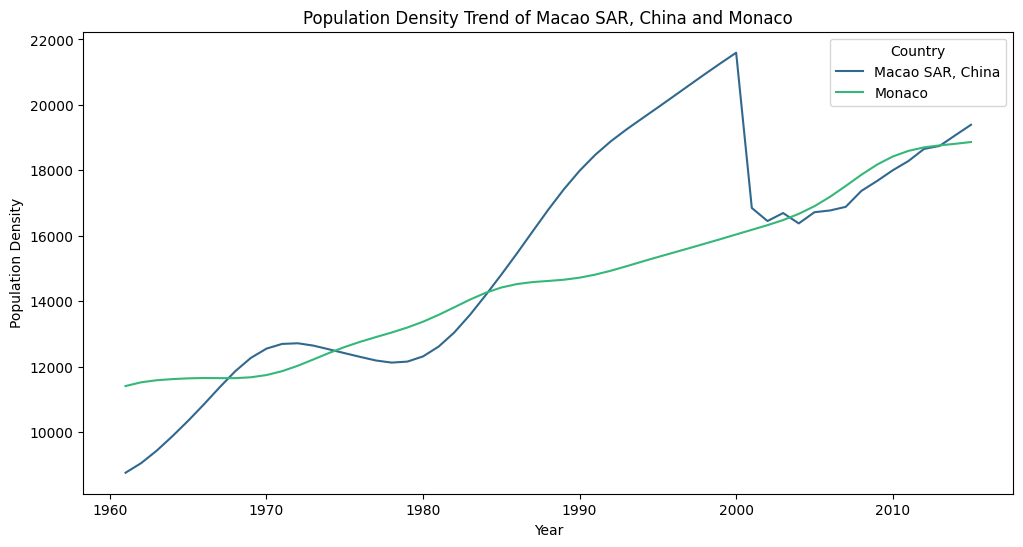

In [57]:
# Graph showing trend of population density of Macao SAR, China and Monaco through out the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted[df_melted['country_name'].isin(['Macao SAR, China', 'Monaco'])], x='year', y='population_density', hue='country_name', palette='viridis')
plt.title("Population Density Trend of Macao SAR, China and Monaco")
plt.xlabel("Year")
plt.ylabel("Population Density")
plt.legend(title='Country')
plt.show()

# Conclusion


*   Summarized the top 20 countries by population density with continent mappings.
*   Visualized population density distributions by country and interval using bar plots.
*   Analyzed population density trends for Macao SAR, China, and Monaco, noting their high population densities.

